In [1]:
#Python program to perform univariate analysis on Sachin Tendulkar’s ODI batting data, 
#focusing on cleaning and analyzing the 'Runs' and '4s' (X4s) columns as ordered categorical variables.

In [2]:
# import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re


In [5]:
# Load the Excel file
df = pd.read_csv('D:\\Phani\\etechguild\\syllabus\\demo\\lessons\\python\\EDA\\data sheets\\tendulkar_ODI.csv')

# Preview the data
print("Initial Data Snapshot:")
print(df[['Runs', '4s']].head())

Initial Data Snapshot:
  Runs 4s
0    0  0
1    0  0
2   36  5
3   19  1
4   31  3


In [6]:
# Clean 'Runs' column
def clean_runs(value):
    if isinstance(value, str):
        if value == 'DNB' or value == 'TDNB':
            return None
        value = re.sub(r'\*', '', value)  # Remove asterisk for not out
        if value.isdigit():
            return int(value)
        else:
            return None
    return value

In [7]:
df['Runs_clean'] = df['Runs'].apply(clean_runs)

In [8]:
# Clean '4s' column
df['X4s_clean'] = df['4s'].replace('-', None).astype(float)

In [9]:
# Drop rows with missing cleaned values
df_cleaned = df.dropna(subset=['Runs_clean', 'X4s_clean'])

print("\nCleaned Data Snapshot:")
print(df_cleaned[['Runs_clean', 'X4s_clean']].head())


✅ Cleaned Data Snapshot:
   Runs_clean  X4s_clean
0         0.0        0.0
1         0.0        0.0
2        36.0        5.0
3        19.0        1.0
4        31.0        3.0



📈 Runs Summary:
count    292.000000
mean      39.448630
std       39.933374
min        0.000000
25%        7.000000
50%       27.500000
75%       62.250000
max      200.000000
Name: Runs_clean, dtype: float64


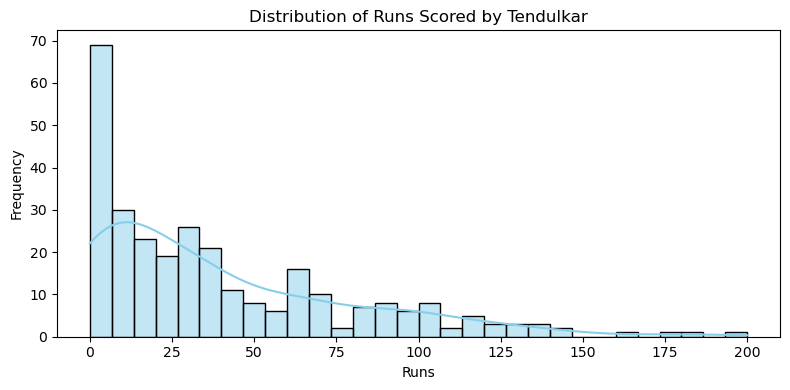

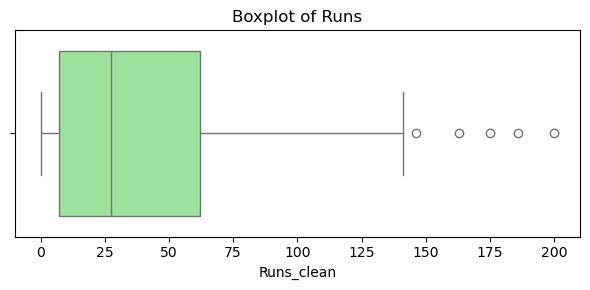

In [10]:
#Univariate Analysis of 'Runs'
# Summary statistics
print("\n📈 Runs Summary:")
print(df_cleaned['Runs_clean'].describe())

# Histogram
plt.figure(figsize=(8, 4))
sns.histplot(df_cleaned['Runs_clean'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Runs Scored by Tendulkar")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(6, 3))
sns.boxplot(x=df_cleaned['Runs_clean'], color='lightgreen')
plt.title("Boxplot of Runs")
plt.tight_layout()
plt.show()



📈 4s Summary:
count    292.000000
mean       4.506849
std        4.730172
min        0.000000
25%        1.000000
50%        3.000000
75%        7.000000
max       25.000000
Name: X4s_clean, dtype: float64


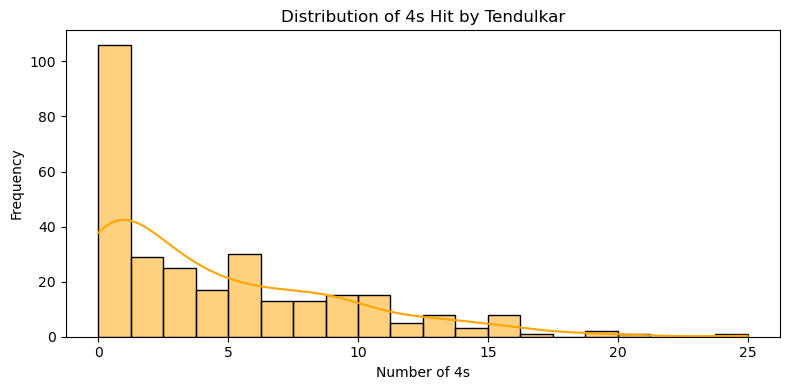

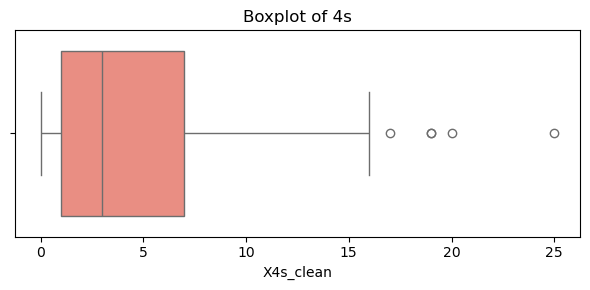

In [11]:
#Univariate Analysis of 'X4s'
# Summary statistics
print("\n 4s Summary:")
print(df_cleaned['X4s_clean'].describe())

# Histogram
plt.figure(figsize=(8, 4))
sns.histplot(df_cleaned['X4s_clean'], bins=20, kde=True, color='orange')
plt.title("Distribution of 4s Hit by Tendulkar")
plt.xlabel("Number of 4s")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(6, 3))
sns.boxplot(x=df_cleaned['X4s_clean'], color='salmon')
plt.title("Boxplot of 4s")
plt.tight_layout()
plt.show()
